# Ярус A: проверка теории на малых задачах

Демонстрация экспериментов, проверяющих Теоремы 1–4 и леммы диплома на задачах
с точно вычислимыми решениями (float64, полный градиент, точные $w^*$ и $\widetilde w^*$ методом Ньютона).

Все ячейки читают **сохранённые результаты** (`theory_bench/results/*.json`) — GPU не нужен.
Перезапуск любого эксперимента: `python -m theory_bench.experiments <a0|a1|...|s2> --device cuda:0`.

In [1]:
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RES = "../theory_bench/results"
FIGS = "../theory_bench/figs"
pd.set_option("display.precision", 4)

def show(name, width=900):
    display(Image(filename=os.path.join(FIGS, name), width=width))


## A0. Юнит-тест стенда

AdamW на диагональной квадратичной задаче: после стабилизации $\hat D$ траектория должна
совпасть с аналитическим решением изменённой задачи $\widetilde w^{*,i} = b_i/(a_i + \lambda d^i)$,
при этом градиент **исходной** задачи остаётся большим.

In [2]:
a0 = json.load(open(f"{RES}/a0.json"))
print(f"относительная ошибка до аналитического w̃*: {a0['rel_err_to_analytic']:.2e}")
print(f"||∇F̃||² = {a0['gFt2_final']:.2e},  ||∇F||² = {a0['gF2_final']:.3f}")
print(f"отношение критериев: {a0['ratio_gF2_gFt2']:.2e}")

относительная ошибка до аналитического w̃*: 7.80e-17
||∇F̃||² = 7.76e-31,  ||∇F||² = 0.109
отношение критериев: 1.40e+29


## A1. Главная иллюстрация: какой критерий убывает

У методов с затуханием весов (W) убывает $\|\nabla \widetilde F_t\|^2$, а $\|\nabla F\|^2$
выходит на плато; у L2/WH — зеркально. Линия — медиана, заливка — разброс по 5 запускам.

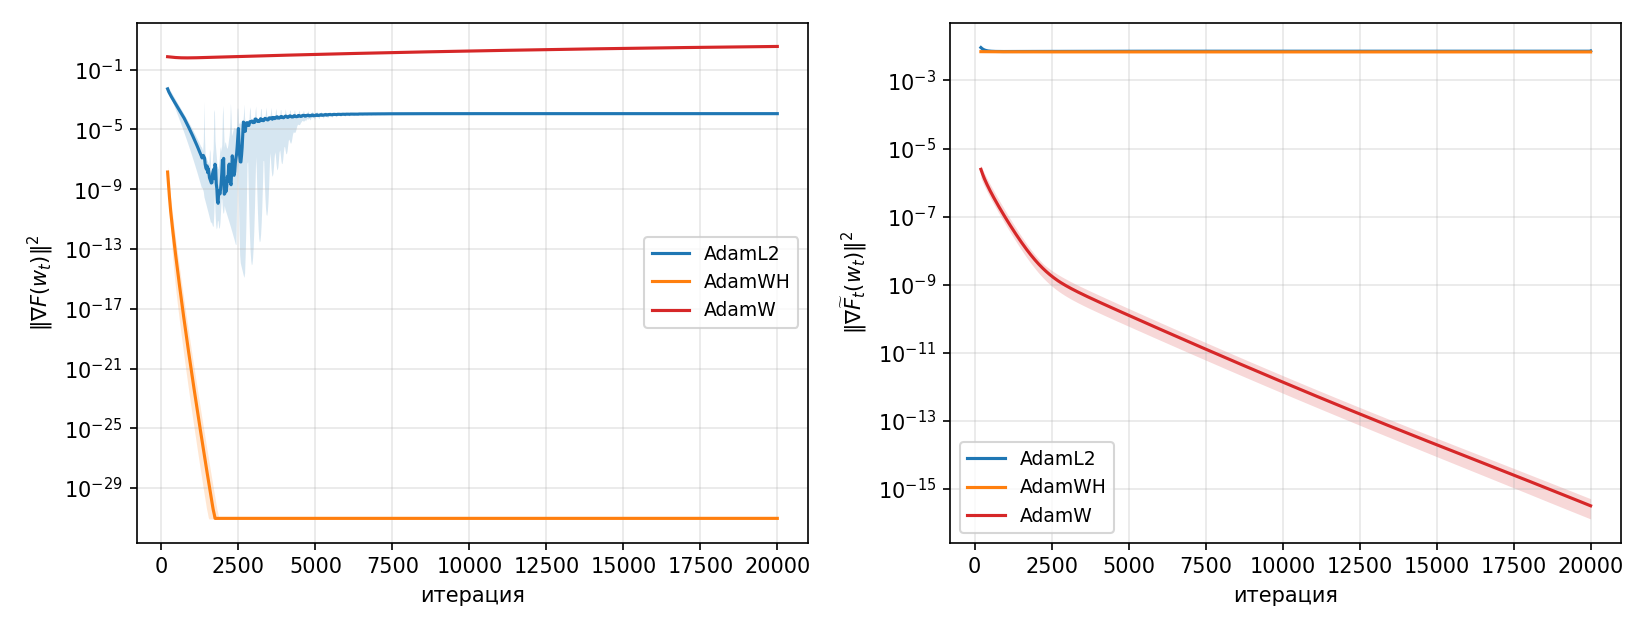

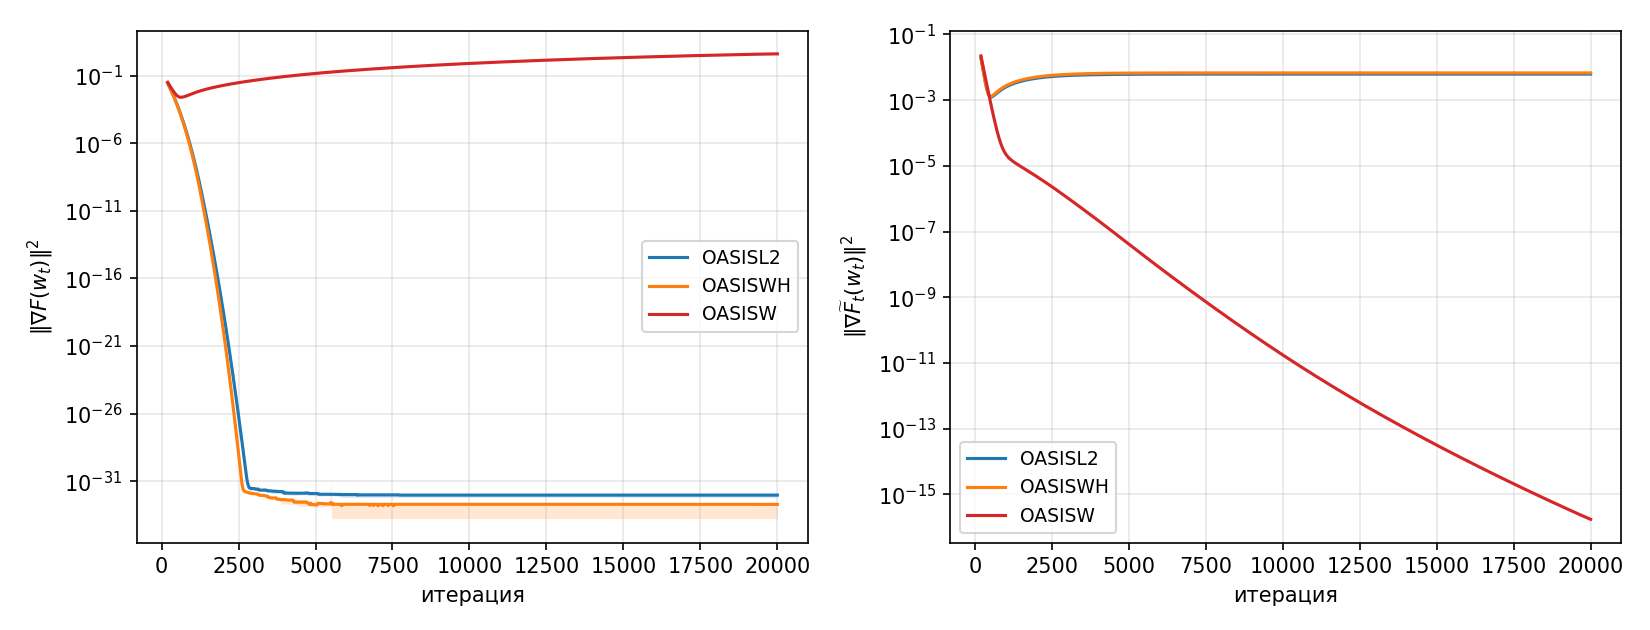

In [3]:
show("fig_main_adam.png")
show("fig_main_oasis.png")

In [4]:
a1 = json.load(open(f"{RES}/a1.json"))
rows = []
for k, v in a1.items():
    task, upd, mode = k.split("|")
    rows.append(dict(task=task, update=upd, mode=mode, eta=v["eta"],
                     gF2_final=v["gF2_final"], gFt2_final=v["gFt2_final"]))
pd.DataFrame(rows).pivot_table(index=["task", "update"], columns="mode",
                               values=["gF2_final", "gFt2_final"], aggfunc="first")

gF2_final                      gFt2_final              \
mode                       l2        w          wh         l2           w   
task      update                                                            
diagquad  linear   7.9103e-30   0.8354  7.5473e-30     1.0162  2.3194e-22   
          squares  6.3607e-03   0.1370  5.9961e-03     0.1078  1.9194e-02   
mushrooms linear   9.6321e-33   4.0334  1.9853e-33     0.0062  1.7447e-16   
          squares  1.1483e-04   3.6055  9.4285e-32     0.0074  3.1913e-16   
quad      linear   1.7485e-01  27.8549  1.7432e-01  1667.9653  6.2481e-15   
          squares  2.3881e-01   0.3090  8.6575e-02     0.3187  2.1737e-01   

                              
mode                      wh  
task      update              
diagquad  linear      1.0017  
          squares     0.0833  
mushrooms linear      0.0067  
          squares     0.0069  
quad      linear   1665.9874  
          squares     0.1637

## A4. Лемма о нижней оценке расстояния между решениями

$L_F\,\|\widetilde w^*_t - w^*\| \ge \|(I-D_t)\,\nabla r(\widetilde w^*_t)\|$ — проверка на 27
конфигурациях с точными решениями (Ньютон). Все точки обязаны лежать выше диагонали.

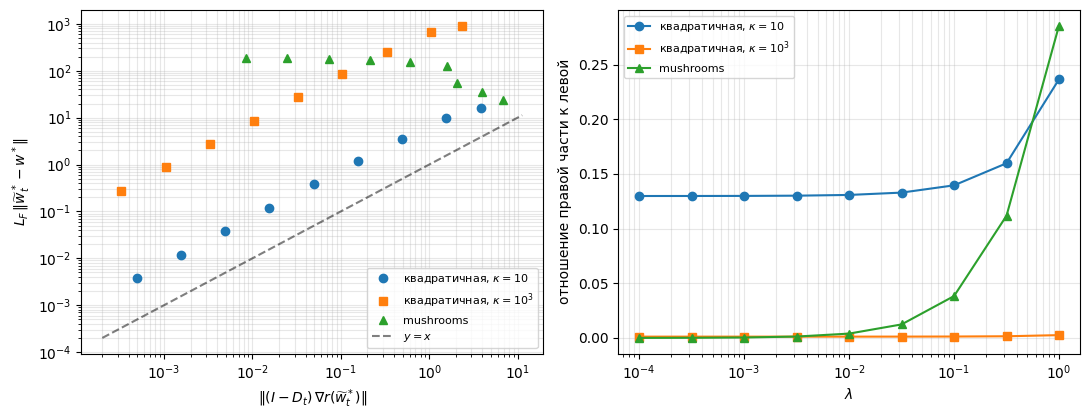

нарушений неравенства: 0 из 27


In [5]:
a4 = json.load(open(f"{RES}/a4.json"))
pts = a4["points"]
names = {"diagquad10": "квадратичная, $\\kappa=10$", "diagquad1e3": "квадратичная, $\\kappa=10^3$", "mushrooms": "mushrooms"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for t, mk in (("diagquad10", "o"), ("diagquad1e3", "s"), ("mushrooms", "^")):
    p = [q for q in pts if q["task"] == t]
    axes[0].loglog([q["RHS"] for q in p], [q["LHS"] for q in p], mk, label=names[t])
    axes[1].semilogx([q["lam"] for q in p], [q["tight"] for q in p], mk + "-", label=names[t])
lims = axes[0].get_xlim()
axes[0].loglog(lims, lims, "k--", alpha=0.5, label="$y=x$")
axes[0].set_xlabel(r"$\|(I-D_t)\,\nabla r(\widetilde w^*_t)\|$"); axes[0].set_ylabel(r"$L_F\,\|\widetilde w^*_t-w^*\|$")
axes[1].set_xlabel(r"$\lambda$"); axes[1].set_ylabel("отношение правой части к левой")
for a in axes: a.grid(alpha=0.3, which="both"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("нарушений неравенства:", len(a4["violations"]), "из", len(pts))

## A5. Механизм адаптивной регуляризации

Элементы $d^i$ стационарной матрицы коррелируют с частотой признаков — weight decay
почти не штрафует редкие координаты.

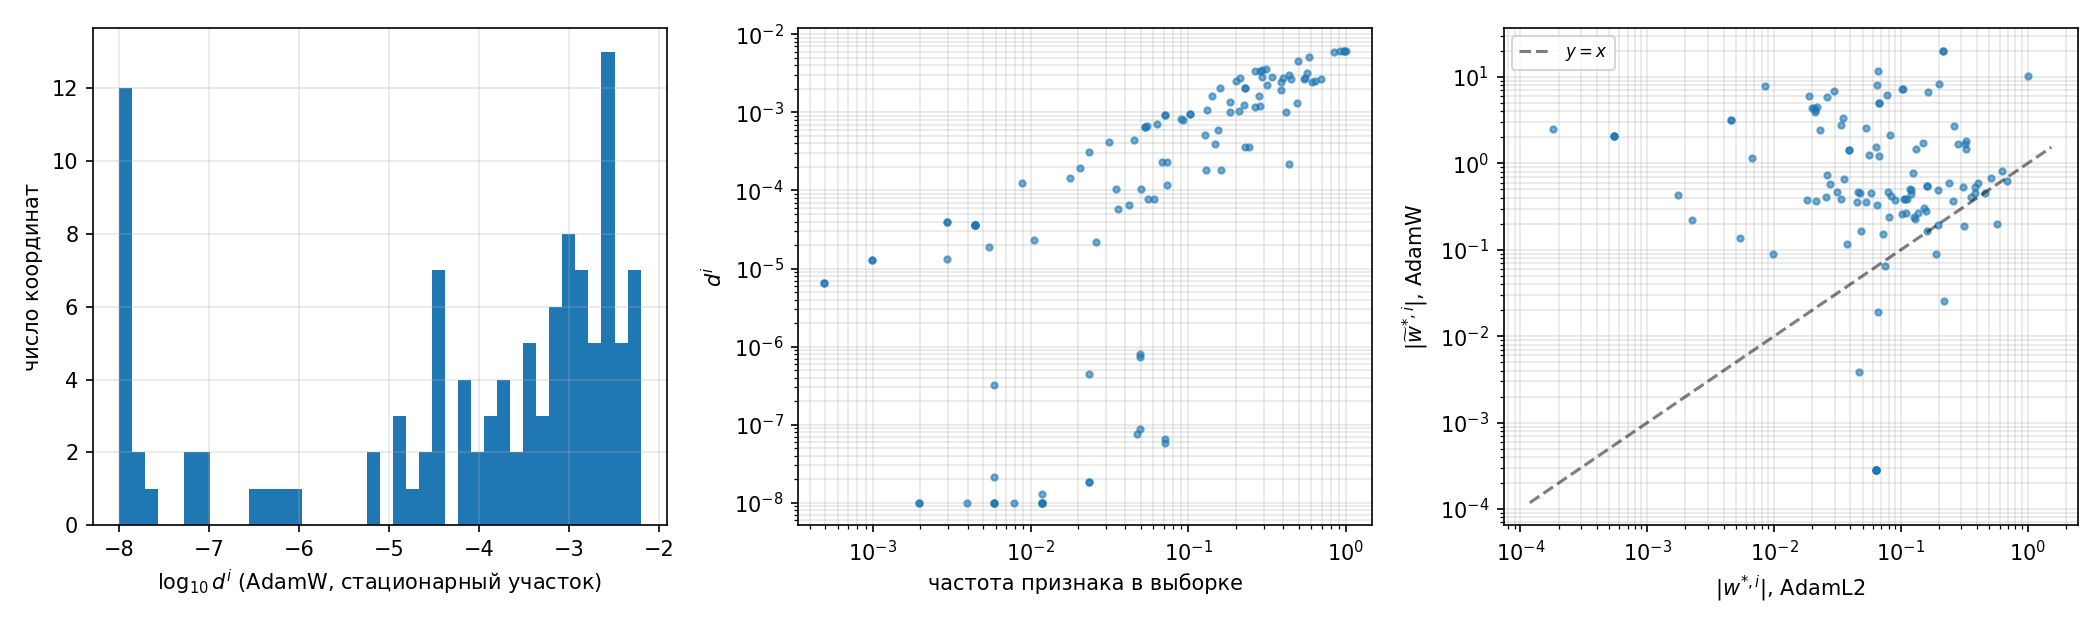

Spearman(d, частота): 0.876
средний |w| на редких признаках: AdamW 3.47 vs AdamL2 0.07


In [6]:
show("a5_dinf.png")
a5 = json.load(open(f"{RES}/a5.json"))
print("Spearman(d, частота):", round(a5["spearman_d_vs_freq"]["corr"], 3))
print("средний |w| на редких признаках: AdamW", round(a5["mean_abs_w_rare"]["adamw"], 2),
      "vs AdamL2", round(a5["mean_abs_w_rare"]["adaml2"], 2))

## A3. Теорема 2: линейная скорость к $\widetilde w^*_t$

Расстояние до движущейся цели убывает линейно; теоретическая скорость — корректная
(консервативная) гарантия: эмпирическая скорость всюду выше.

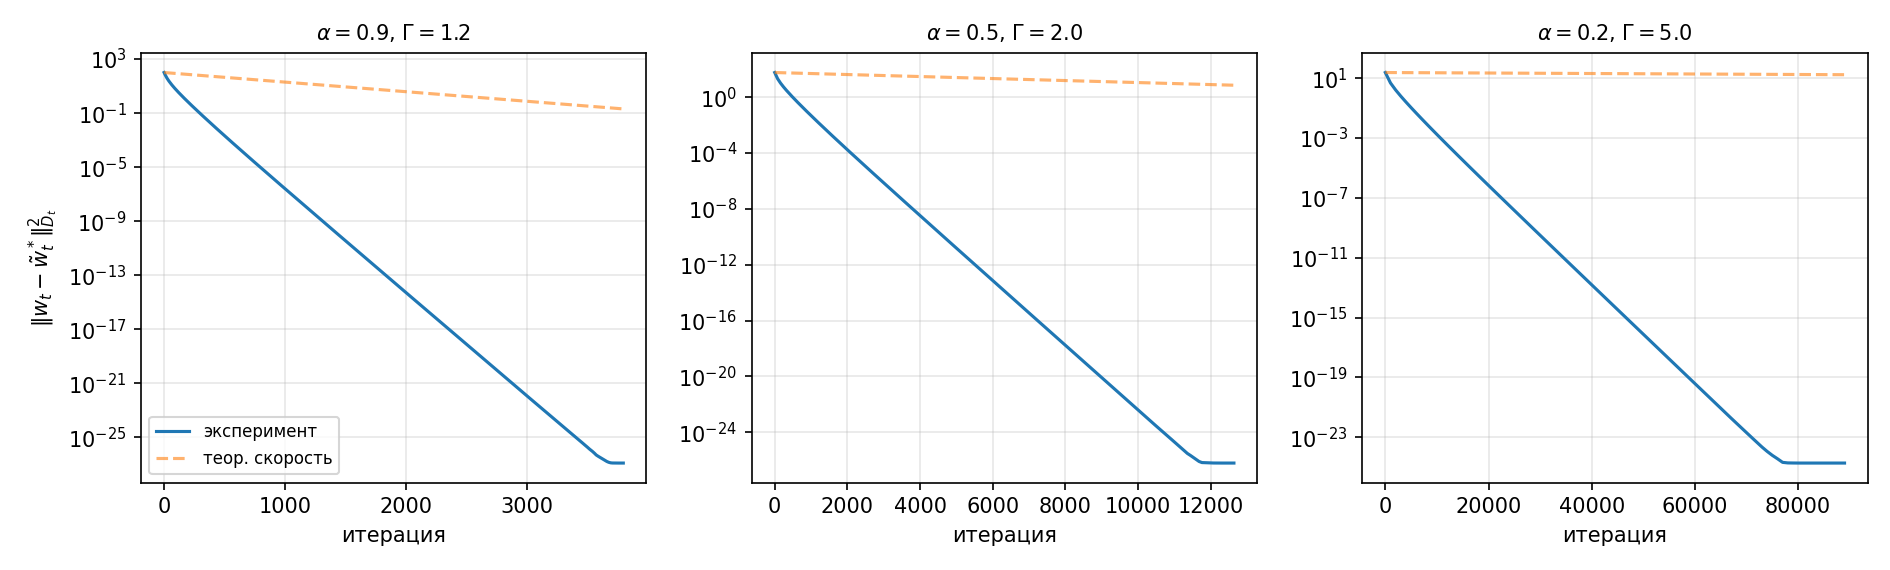

,alpha,Gamma,eta,tag,rate_emp,rate_theory,ratio,R2_final
0,0.9,1.2,7.1840e-03,theory,0.0178,1.6314e-03,10.9213,1.2803e-27
1,0.9,1.2,5.0000e-02,practical,0.1273,1.1354e-02,11.2090,2.9601e-29
2,0.5,2.0,1.2615e-03,theory,0.0054,1.6558e-04,32.6684,6.1108e-27
3,0.5,2.0,5.0000e-02,practical,0.2259,6.5625e-03,34.4228,7.8851e-30
4,0.2,5.0,7.4014e-05,theory,0.0008,3.7747e-06,204.0242,1.9121e-25
5,0.2,5.0,3.7007e-03,practical,0.0390,1.8873e-04,206.8865,1.2934e-28


In [7]:
show("a3_linear_rate.png")
a3 = json.load(open(f"{RES}/a3.json"))
pd.DataFrame([dict(alpha=r["cfg"]["alpha"], Gamma=r["cfg"]["gamma"], eta=r["eta"], tag=r["tag"],
                   rate_emp=r["rate_emp_per_iter"], rate_theory=r["rate_theory_per_iter"],
                   ratio=r["ratio_emp_over_theory"], R2_final=r["R2_final"]) for r in a3["runs"]])

## A2. Лемма об эволюции $D_t$ (стохастический режим)

Прямое подтверждение: $\max_t\|\hat D_{t+1}-\hat D_t\|_\infty \propto (1-\beta)$,
граница леммы не нарушается. Уровень плато $\|\nabla\widetilde F\|^2$ при этом задаётся
шумовым членом (дрейфовый член — оценка худшего случая).

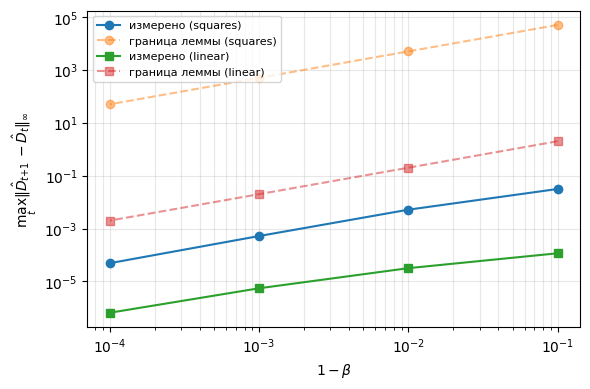

In [8]:
a2 = json.load(open(f"{RES}/a2.json"))
rr = [r for r in a2["runs"] if not r.get("is_baseline")]
fig, ax = plt.subplots(figsize=(6, 4))
for upd, mk in (("squares", "o"), ("linear", "s")):
    xs = [1 - r["beta"] for r in rr if r["update"] == upd]
    ys = [r["dD_max"] for r in rr if r["update"] == upd]
    bs = [r["rho_beta_bound"] for r in rr if r["update"] == upd]
    ax.loglog(xs, ys, mk + "-", label=f"измерено ({upd})")
    ax.loglog(xs, bs, mk + "--", alpha=0.5, label=f"граница леммы ({upd})")
ax.set_xlabel(r"$1-\beta$"); ax.set_ylabel(r"$\max_t\|\hat D_{t+1}-\hat D_t\|_\infty$")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## A7. Мосты к практическому Adam и стабилизация $D_t$

Замена срезки $\alpha$ на практическую добавку $\epsilon$, включение $\beta_1=0.9$ и
bias-correction не меняют картину; поэлементного предела $D_t$ нет — стабилизируется масштаб.

(a) clamp(α) vs +ε: падение ||∇F̃||², порядков:
   clamp_1e-8   15.4
   eps_1e-8     15.4
   clamp_1e-4   21.5
   eps_1e-4     16.3
(b) β₁ / bias-correction: финальные ||∇F̃||²:
   beta1=0.0|bc=False     3.19e-16
   beta1=0.0|bc=True      1.18e-10
   beta1=0.9|bc=False     3.82e-16
   beta1=0.9|bc=True      1.04e-15


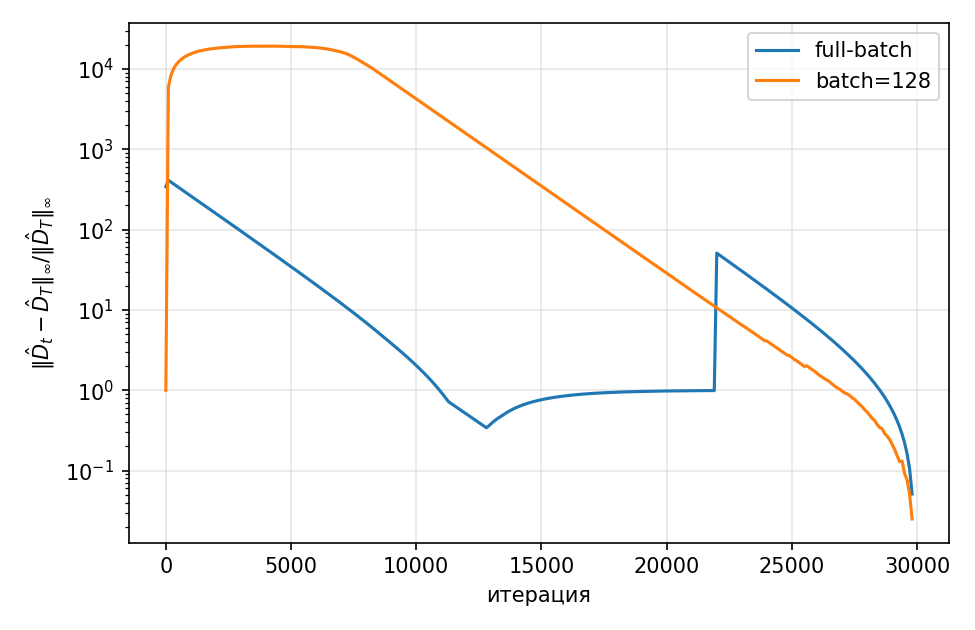

In [9]:
a7 = json.load(open(f"{RES}/a7.json"))
print("(a) clamp(α) vs +ε: падение ||∇F̃||², порядков:")
for k, v in a7["a_alpha_vs_eps"].items():
    print(f"   {k:12s} {v['gFt2_drop_orders']:.1f}")
print("(b) β₁ / bias-correction: финальные ||∇F̃||²:")
for k, v in a7["b_beta1_bias_correction"].items():
    print(f"   {k:22s} {v['gFt2_final']:.2e}")
show("a7_dstab.png", width=600)

## S1b, S2. Шумовые члены Теорем 3 и 4

Плато $\mathbb E\|\nabla\widetilde F\|^2 \propto \eta\sigma^2$ (Т3, наклоны 1.000) и
шумовой шар $\mathbb E\|w-\widetilde w^*\|^2_D \propto \eta\sigma^2$ под границей Т4 (наклон 1.03).

s1b {
 "slope_vs_eta|sigma=0.1": 0.9996235629639504,
 "slope_vs_eta|sigma=0.3": 0.9996239188850456,
 "slope_vs_eta|sigma=1.0": 0.9996253213513707,
 "slope_vs_sigma2|eta=0.0003": 0.9999996702387688,
 "slope_vs_sigma2|eta=0.001": 0.9999991912191214,
 "slope_vs_sigma2|eta=0.003": 1.0000017382432849,
 "slope_vs_sigma2|eta=0.01": 1.0000003548932705
}
s2 {
 "slope_vs_eta|sigma=0.1": 1.0270217740913374,
 "slope_vs_eta|sigma=0.3": 1.0270217740913463,
 "slope_vs_eta|sigma=1.0": 1.0270217740913545
}


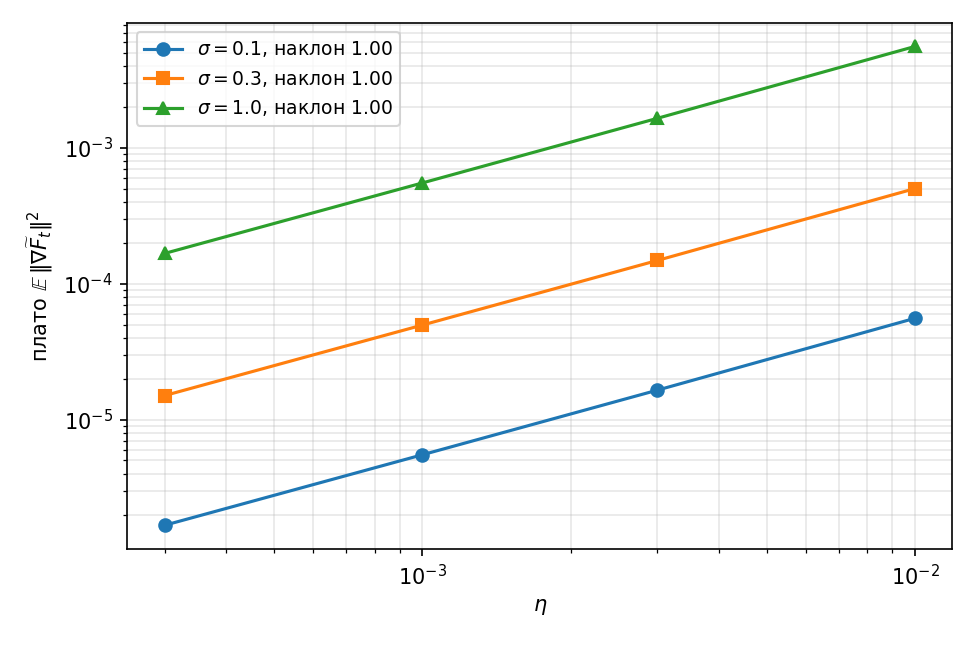

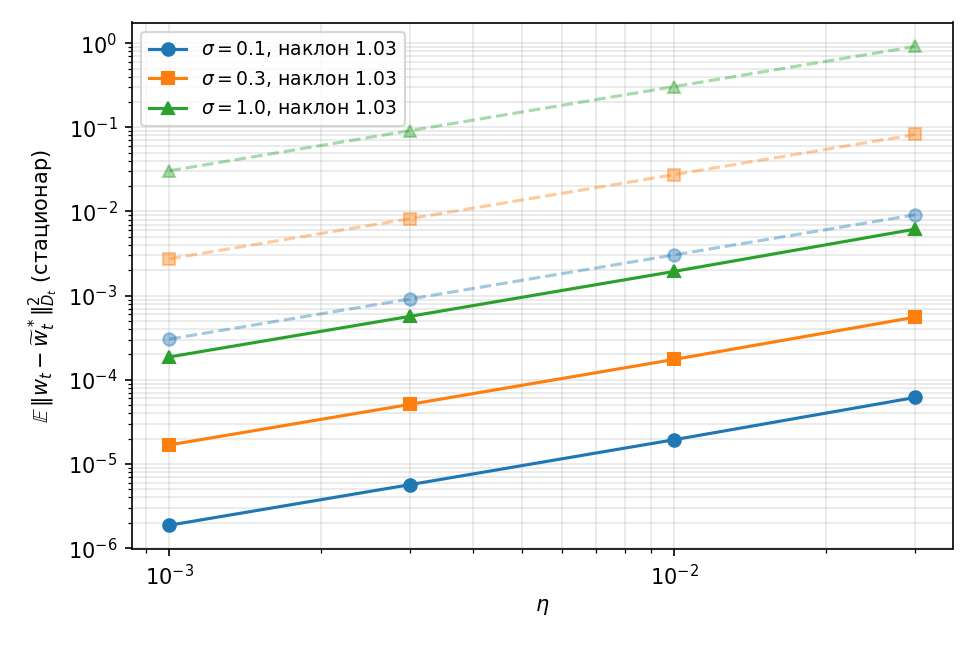

In [10]:
for name, fits_key in (("s1b", "fits"), ("s2", "fits")):
    d = json.load(open(f"{RES}/{name}.json"))
    print(name, json.dumps(d[fits_key], indent=1))
show("s1b_eta_scaling.png", width=600)
show("s2_noise_ball.png", width=600)